# Mass vs Radius

In [50]:
from cProfile import label

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

from numpy import log10
from matplotlib.lines import lineStyles
from openpyxl.styles.builtins import styles

In [51]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Mass vs Radius': ['There is no relationship between planet_mass_earth and planet_radius_earth', 'Greater mass = larger radius (non-linear relationship)']
}
mass_vs_radius = pd.DataFrame(data)
mass_vs_radius

,Hypothesis,Mass vs Radius
0,H0,There is no relationship between planet_mass_e...
1,H1,Greater mass = larger radius (non-linear relat...


In [52]:
# Load the dataset
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [53]:
data['planet_mass_earth'].isna().sum()

np.int64(31)

In [54]:
data['planet_radius_earth'].isna().sum()

np.int64(50)

In [55]:
cleaned_data = data[['planet_mass_earth', 'planet_radius_earth']].dropna()

Missing values in the selected features were minimal (~1.5%),
therefore rows containing NaN values were removed to ensure accurate statistical analysis.

In [56]:
cleaned_data['planet_mass_earth'].describe()

count    6076.000000
mean      395.767791
std      1131.865261
min         0.020000
25%         4.160000
50%         9.150000
75%       181.163100
max      9534.852210
Name: planet_mass_earth, dtype: float64

The histogram of the log-transformed planet mass is used to better visualize the distribution, as the original data is highly skewed. The log transformation reduces the impact of extreme values, making the distribution more interpretable. The vertical dashed line represents the mean, indicating the central tendency of the data.

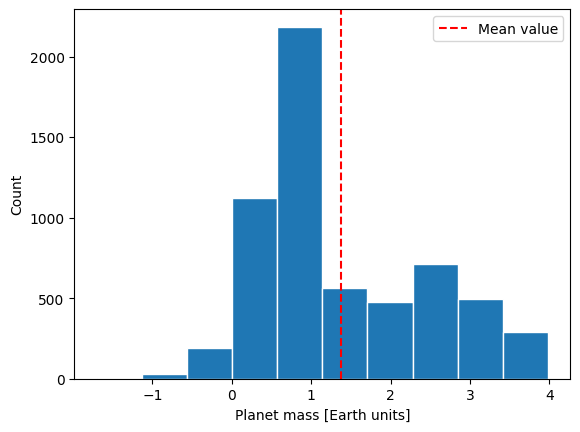

In [57]:
plt.hist(log10(cleaned_data['planet_mass_earth']), edgecolor='white')
mean_value = log10(cleaned_data['planet_mass_earth']).mean()

plt.axvline(mean_value, color='r', linestyle='--', label='Mean value')

plt.xlabel('Planet mass [Earth units]')
plt.ylabel('Count')
plt.legend()
plt.show()

In [58]:
cleaned_data['planet_radius_earth'].describe()

count    6076.000000
mean        5.806160
std         5.407487
min         0.309800
25%         1.820000
50%         2.830000
75%        11.900000
max        87.205870
Name: planet_radius_earth, dtype: float64

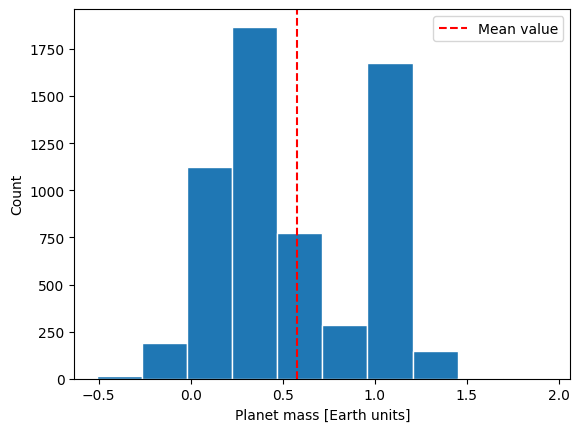

In [59]:
plt.hist(log10(cleaned_data['planet_radius_earth']), edgecolor='white')
mean_value = log10(cleaned_data['planet_radius_earth']).mean()

plt.axvline(mean_value, color='r', linestyle='--', label='Mean value')

plt.xlabel('Planet mass [Earth units]')
plt.ylabel('Count')
plt.legend()
plt.show()

In [60]:
focused_features = cleaned_data[['planet_mass_earth', 'planet_radius_earth']]

In [62]:
st.pearsonr(
    focused_features['planet_mass_earth'],
    focused_features['planet_radius_earth']
)

PearsonRResult(statistic=np.float64(0.4540867226821414), pvalue=np.float64(6.082551772437259e-307))

There is a statistically significant moderate positive correlation between planet mass and planet radius.

As mass increases, radius tends to increase as well, although the relationship is not perfectly linear.

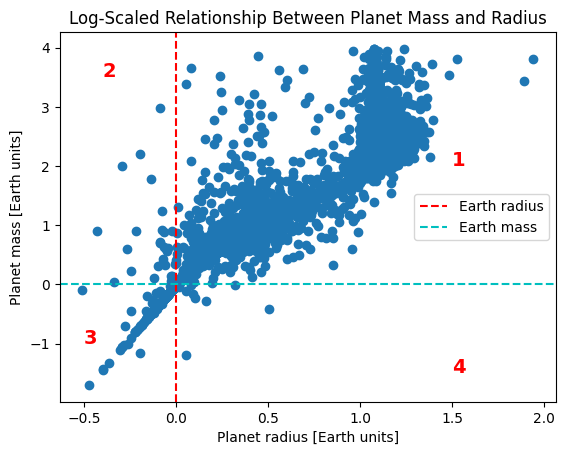

In [92]:
plt.scatter(log10(focused_features['planet_radius_earth']), log10(focused_features['planet_mass_earth']))

plt.axvline(x=0, color='r', linestyle='--', label='Earth radius')
plt.axhline(y=0, color='c', linestyle='--', label='Earth mass')

# Quadrant labels
plt.text(1.5, 2, '1', fontsize=14, fontweight='bold', color='r')
plt.text(-0.4, 3.5, '2', fontsize=14, fontweight='bold', color='r')
plt.text(-0.5, -1, '3', fontsize=14, fontweight='bold', color='r')
plt.text(1.5, -1.5, '4', fontsize=14, fontweight='bold', color='r')

plt.title('Log-Scaled Relationship Between Planet Mass and Radius')
plt.xlabel('Planet radius [Earth units]')
plt.ylabel('Planet mass [Earth units]')
plt.legend()
plt.show()

**Quadrant 1** – Planets with both larger radius and greater mass than Earth

**Quadrant 2** – Planets with smaller radius but greater mass than Earth

**Quadrant 3** – Planets with both smaller radius and lower mass than Earth

**Quadrant 4** – Planets with larger radius but lower mass than Earth

From the observed exoplanets, we can see that a large proportion are significantly larger than Earth in both size and mass.

A speculative hypothesis — which cannot currently be verified — is that if life similar to that on Earth exists on some of the largest observed planets, their populations could potentially reach billions of inhabitants.